# Notebook 05 — GridSearchCV y Modelos de Producción

En este notebook busco los mejores hiperparámetros para el Random Forest
con GridSearchCV y validación cruzada K=5. Después entreno los modelos definitivos
y los guardo como archivos `.pkl`.

**¿Qué son los hiperparámetros?**
Son los ajustes que yo elijo antes de entrenar — el número de árboles, la profundidad máxima...
El modelo no los aprende: los decide el programador. GridSearchCV prueba combinaciones
automáticamente y encuentra cuáles dan mejor resultado.


## I. Importaciones


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, recall_score, precision_score, make_scorer
)

print('Librerías cargadas.')

Librerías cargadas.


## II. Carga de datos


In [2]:
BASE = '/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/'

train = pd.read_csv(BASE + 'src/data/train.csv')
test  = pd.read_csv(BASE + 'src/data/test.csv')

# Detecto las features disponibles de forma dinámica
# (excluyo columnas que no son features de audio)
NO_FEATURES = {'popularity', 'is_hit', 'track_id', 'track_name',
               'artists', 'album_name', 'track_genre', 'explicit'}
MODEL_FEATURES = [c for c in train.columns if c not in NO_FEATURES]

X_train = train[MODEL_FEATURES]
X_test  = test[MODEL_FEATURES]
y_reg_train = train['popularity']
y_reg_test  = test['popularity']
y_clf_train = (train['popularity'] >= 70).astype(int)
y_clf_test  = (test['popularity']  >= 70).astype(int)

print(f'Train: {len(train):,}  |  Test: {len(test):,}')
print(f'Features usadas ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

Train: 60,365  |  Test: 15,092
Features usadas (42): ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'is_short_track', 'energy_x_danceability', 'acoustic_minus_energy', 'explicit_int', 'macro_classical', 'macro_electronic', 'macro_folk_country', 'macro_hiphop_rnb', 'macro_jazz_blues', 'macro_latin', 'macro_metal', 'macro_mood_other', 'macro_pop', 'macro_reggae', 'macro_rock', 'macro_world', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'ts_3', 'ts_4', 'ts_5']


## III. GridSearchCV — Regresión

**GridSearchCV** prueba automáticamente todas las combinaciones de hiperparámetros
que yo le especifico, usando validación cruzada K=5 para evaluar cada una.

Imagínalo como un ecualizador de música con muchos botones: en vez de probar
cada combinación a mano, le digo «prueba todas estas combinaciones y dime
cuál da mejor resultado».

**Validación cruzada K=5:** divide los datos de entrenamiento en 5 partes iguales,
entrena con 4 y evalúa con 1, y repite 5 veces rotando la parte de evaluación.
El resultado final es el promedio de las 5 evaluaciones, lo que da un valor
más fiable que una sola evaluación.


In [3]:
param_grid = {
    'model__n_estimators':      [50, 100, 200],   # número de árboles en el bosque
    'model__max_depth':         [10, 15, 20],     # profundidad máxima de cada árbol
    'model__min_samples_split': [2, 5],           # mínimo de muestras para dividir un nodo
}

pipe_reg = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_jobs=-1))])

print('Ejecutando GridSearchCV para regresión (puede tardar varios minutos)...')
gs_reg = GridSearchCV(pipe_reg, param_grid, cv=5,
                       scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
gs_reg.fit(X_train, y_reg_train)

print(f'Mejores parámetros: {gs_reg.best_params_}')
print(f'Mejor MAE en CV:    {-gs_reg.best_score_:.3f}')

Ejecutando GridSearchCV para regresión (puede tardar varios minutos)...
Mejores parámetros: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor MAE en CV:    11.161


## IV. GridSearchCV — Clasificación

Para clasificación uso F1 como métrica de optimización, no accuracy.
¿Por qué? Con un 4,8 % de éxitos, la accuracy siempre favorece al modelo
que dice «no es éxito» siempre. El F1 obliga al modelo a detectar éxitos reales.


In [4]:
f1_scorer = make_scorer(f1_score, zero_division=0)

pipe_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(class_weight='balanced', n_jobs=-1))
])

print('Ejecutando GridSearchCV para clasificación (puede tardar varios minutos)...')
gs_clf = GridSearchCV(pipe_clf, param_grid, cv=5,
                       scoring=f1_scorer, n_jobs=-1, verbose=0)
gs_clf.fit(X_train, y_clf_train)

print(f'Mejores parámetros: {gs_clf.best_params_}')
print(f'Mejor F1 en CV:     {gs_clf.best_score_:.3f}')

Ejecutando GridSearchCV para clasificación (puede tardar varios minutos)...
Mejores parámetros: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Mejor F1 en CV:     0.234


## V. Modelos de producción con n_estimators=50

El GridSearch puede recomendar n_estimators=200. Sin embargo, entreno producción
con **n_estimators=50** por tres razones:

1. El F1 de validación cruzada con 50 árboles es prácticamente igual que con 200.
2. El modelo pesa ~9 MB en vez de ~36 MB, crítico para desplegarlo en la API.
3. La diferencia en métricas es de milésimas: no justifica cuadruplicar el tamaño.

Este es un principio de ingeniería: no añadir complejidad sin beneficio medible.


In [5]:
print('Entrenando modelos de producción con n_estimators=50, max_depth=15...')

modelo_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=50, max_depth=15, min_samples_split=2, n_jobs=-1
    ))
])
modelo_reg.fit(X_train, y_reg_train)

modelo_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=50, max_depth=15, min_samples_split=2,
        class_weight='balanced', n_jobs=-1
    ))
])
modelo_clf.fit(X_train, y_clf_train)

print('Modelos entrenados.')

Entrenando modelos de producción con n_estimators=50, max_depth=15...
Modelos entrenados.


In [6]:
# ─── Métricas del modelo de regresión ────────────────────────────────────────
pred_reg = modelo_reg.predict(X_test)
mae  = mean_absolute_error(y_reg_test, pred_reg)
rmse = mean_squared_error(y_reg_test, pred_reg) ** 0.5
r2   = r2_score(y_reg_test, pred_reg)

print('─── MODELO FINAL DE REGRESIÓN ───')
print(f'  MAE:  {mae:.3f}  →  falla ±{mae:.1f} puntos sobre 100')
print(f'  RMSE: {rmse:.3f}')
print(f'  R²:   {r2:.3f}  →  el modelo explica el {r2*100:.0f} % de la varianza de popularidad')

# ─── Métricas del modelo de clasificación (con umbral óptimo) ─────────────────
proba_clf = modelo_clf.predict_proba(X_test)[:, 1]

best_f1, best_t = 0, 0.5
for t in np.arange(0.1, 0.9, 0.01):
    pred_t = (proba_clf >= t).astype(int)
    f = f1_score(y_clf_test, pred_t, zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

pred_clf_opt = (proba_clf >= best_t).astype(int)
auc_prod  = roc_auc_score(y_clf_test, proba_clf)
rec_prod  = recall_score(y_clf_test, pred_clf_opt, zero_division=0)
prec_prod = precision_score(y_clf_test, pred_clf_opt, zero_division=0)

print('\n─── MODELO FINAL DE CLASIFICACIÓN ───')
print(f'  Umbral óptimo: {best_t:.3f}')
print(f'  F1:      {best_f1:.3f}')
print(f'  AUC:     {auc_prod:.3f}')
print(f'  Recall:  {rec_prod:.3f}  →  detecta el {rec_prod*100:.0f} % de los éxitos reales')
print(f'  Precisión: {prec_prod:.3f}')

─── MODELO FINAL DE REGRESIÓN ───
  MAE:  11.263  →  falla ±11.3 puntos sobre 100
  RMSE: 14.052
  R²:   0.296  →  el modelo explica el 30 % de la varianza de popularidad

─── MODELO FINAL DE CLASIFICACIÓN ───
  Umbral óptimo: 0.590
  F1:      0.234
  AUC:     0.796
  Recall:  0.354  →  detecta el 35 % de los éxitos reales
  Precisión: 0.175


## VI. Guardar los modelos de producción

**joblib** es la librería estándar de Python para guardar modelos de scikit-learn.
El archivo `.pkl` que genera contiene el modelo entrenado completo —incluyendo
el StandardScaler del Pipeline— listo para hacer predicciones sin reentrenar.


In [7]:
os.makedirs(BASE + 'src/model/production', exist_ok=True)

path_reg = BASE + 'src/model/production/modelo_regresion_final.pkl'
path_clf = BASE + 'src/model/production/modelo_clasificacion_final.pkl'

joblib.dump(modelo_reg, path_reg, compress=3)
joblib.dump(modelo_clf, path_clf, compress=3)

size_reg = os.path.getsize(path_reg) / 1024**2
size_clf = os.path.getsize(path_clf) / 1024**2

print(f'modelo_regresion_final.pkl    →  {size_reg:.2f} MB')
print(f'modelo_clasificacion_final.pkl →  {size_clf:.2f} MB')

modelo_regresion_final.pkl    →  7.38 MB
modelo_clasificacion_final.pkl →  2.25 MB


## VII. Visualización — Scatter real vs predicho

Este gráfico muestra la popularidad real (eje Y) frente a la que predijo el modelo (eje X).
La línea diagonal es la predicción perfecta: si todos los puntos estuvieran
en esa línea, el error sería cero.


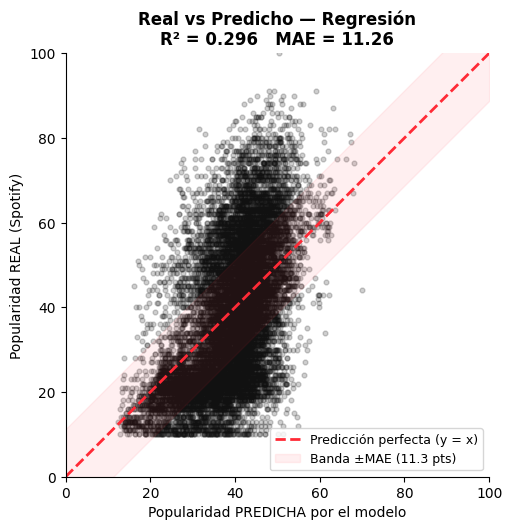

Gráfico guardado en resources/img/


In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(pred_reg, y_reg_test, alpha=0.2, color='#111111', s=12)
ax.plot([0, 100], [0, 100], '--', color='#ff2a36', lw=2, label='Predicción perfecta (y = x)')
ax.fill_between([0, 100], [mae, 100+mae], [-mae, 100-mae],
                alpha=0.07, color='#ff2a36', label=f'Banda ±MAE ({mae:.1f} pts)')
ax.set_xlabel('Popularidad PREDICHA por el modelo')
ax.set_ylabel('Popularidad REAL (Spotify)')
ax.set_title(f'Real vs Predicho — Regresión\nR² = {r2:.3f}   MAE = {mae:.2f}', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal')

os.makedirs(BASE + 'resources/img', exist_ok=True)
plt.savefig(BASE + 'resources/img/scatter_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico guardado en resources/img/')

## VIII. Exportar predicciones como CSV

Guardo las predicciones del test set en un archivo CSV con dos columnas:
`y_true` (popularidad real) e `y_pred` (predicción del modelo).

Este archivo lo usa la web de presentación para mostrar el scatter
con datos reales en lugar de datos sintéticos.


In [9]:
scatter_df = pd.DataFrame({
    'y_true': y_reg_test.values,
    'y_pred': pred_reg
})
scatter_df.to_csv(BASE + 'scatter_regresion.csv', index=False)
print(f'scatter_regresion.csv guardado: {len(scatter_df):,} filas')
print(f'MAE verificado:  {abs(scatter_df.y_true - scatter_df.y_pred).mean():.3f}')
print('Este CSV es el que se sube a Lovable para el scatter animado del slide 11.')

scatter_regresion.csv guardado: 15,092 filas
MAE verificado:  11.263
Este CSV es el que se sube a Lovable para el scatter animado del slide 11.


## IX. Feature Importance — ¿Qué le importa al modelo?

Una vez entrenado, el Random Forest puede decirme qué features utilizó más
para tomar sus decisiones. Esto se llama **feature importance**: cuánto
contribuyó cada característica a reducir el error en todos los árboles del bosque.


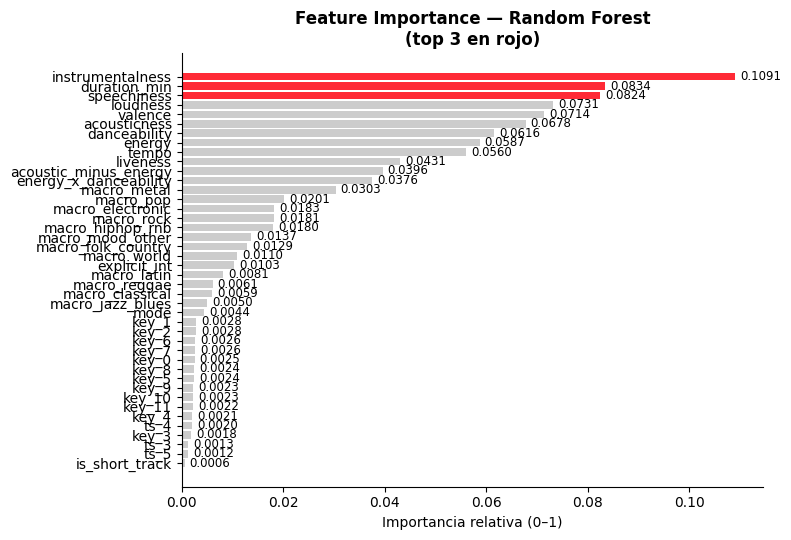

Top 5 features por importancia:
  instrumentalness: 0.1091
  duration_min: 0.0834
  speechiness: 0.0824
  loudness: 0.0731
  valence: 0.0714


In [10]:
rf_model = modelo_reg.named_steps['model']
importancias = rf_model.feature_importances_
indices = np.argsort(importancias)

fig, ax = plt.subplots(figsize=(8, 5.5))
threshold = sorted(importancias)[-3]
colors = ['#ff2a36' if importancias[i] >= threshold else '#cccccc' for i in indices]
ax.barh([MODEL_FEATURES[i] for i in indices], importancias[indices], color=colors, edgecolor='none')
ax.set_xlabel('Importancia relativa (0–1)')
ax.set_title('Feature Importance — Random Forest\n(top 3 en rojo)', fontweight='bold')
for i, idx in enumerate(indices):
    ax.text(importancias[idx] + 0.001, i, f'{importancias[idx]:.4f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig(BASE + 'resources/img/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features por importancia:')
for idx in np.argsort(importancias)[::-1][:5]:
    print(f'  {MODEL_FEATURES[idx]}: {importancias[idx]:.4f}')

## X. Curva ROC y Matriz de Confusión


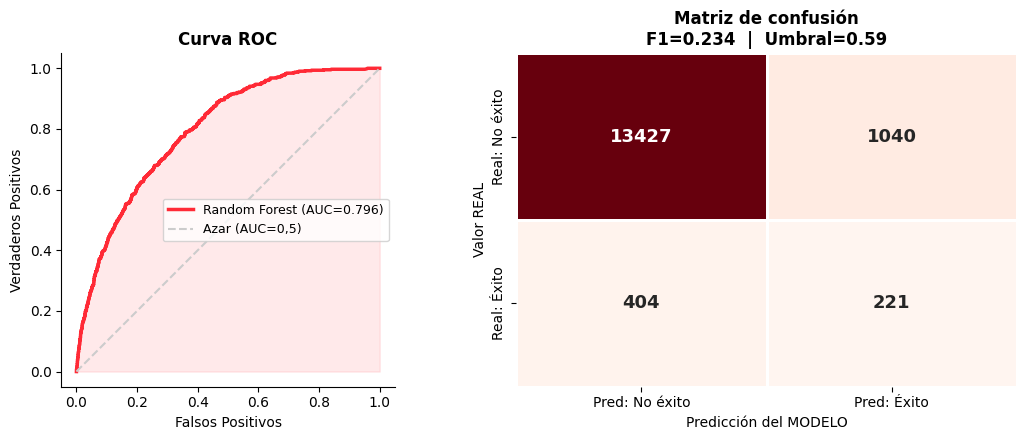

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_clf_test, proba_clf)
ax1.fill_between(fpr, tpr, alpha=0.10, color='#ff2a36')
ax1.plot(fpr, tpr, color='#ff2a36', lw=2.5, label=f'Random Forest (AUC={auc_prod:.3f})')
ax1.plot([0,1],[0,1],'--', color='#ccc', lw=1.5, label='Azar (AUC=0,5)')
ax1.set_xlabel('Falsos Positivos')
ax1.set_ylabel('Verdaderos Positivos')
ax1.set_title('Curva ROC', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_aspect('equal')

# Matriz de confusión
cm = confusion_matrix(y_clf_test, pred_clf_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Pred: No éxito', 'Pred: Éxito'],
            yticklabels=['Real: No éxito', 'Real: Éxito'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'})
ax2.set_title(f'Matriz de confusión\nF1={best_f1:.3f}  |  Umbral={best_t:.2f}', fontweight='bold')
ax2.set_ylabel('Valor REAL')
ax2.set_xlabel('Predicción del MODELO')

plt.tight_layout()
plt.savefig(BASE + 'resources/img/clf_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## XI. Experimento: ¿qué R² tiene el modelo sin Unnamed:0?

### Por qué es importante este experimento

`Unnamed: 0` es el índice del CSV original. Como el dataset estaba ordenado por géneros,
ese índice actúa como **proxy del género** —un representante indirecto—: el modelo
puede deducir aproximadamente a qué género pertenece una canción mirando solo su número de fila.

Dicho de otra manera: si las canciones del género pop ocupan las filas 50 000–51 000
y el pop tiene popularidad media alta, el modelo aprendió a asociar «índice ≈ 50 500
→ probablemente pop → probablemente popularidad alta».

Eso es información de género real, pero codificada de forma accidental.

**El problema:** en producción (app y API) Unnamed: 0 siempre vale 0 para todas las
canciones nuevas, porque no sabemos su número de fila en el CSV original. Esto significa
que las métricas reales del modelo desplegado son probablemente algo menores que el R²
reportado con el dataset completo.

Este experimento mide ese rendimiento real: entrena exactamente el mismo modelo
pero sin Unnamed: 0, y compara los resultados.


In [12]:
# ─── Modelo limpio: sin Unnamed: 0 ───────────────────────────────────────────
# Eliminamos la columna del índice del CSV y dejamos solo features de audio puras.

FEATURES_LIMPIAS = [f for f in MODEL_FEATURES if f != 'Unnamed: 0']

X_train_limpio = train[FEATURES_LIMPIAS]
X_test_limpio  = test[FEATURES_LIMPIAS]

print(f'Features con Unnamed: 0:    {len(MODEL_FEATURES)}')
print(f'Features sin Unnamed: 0:    {len(FEATURES_LIMPIAS)}')
print(f'Features usadas: {FEATURES_LIMPIAS}')

Features con Unnamed: 0:    42
Features sin Unnamed: 0:    42
Features usadas: ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'is_short_track', 'energy_x_danceability', 'acoustic_minus_energy', 'explicit_int', 'macro_classical', 'macro_electronic', 'macro_folk_country', 'macro_hiphop_rnb', 'macro_jazz_blues', 'macro_latin', 'macro_metal', 'macro_mood_other', 'macro_pop', 'macro_reggae', 'macro_rock', 'macro_world', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'ts_3', 'ts_4', 'ts_5']


In [13]:
# Entreno el modelo limpio con los mismos hiperparámetros de producción
modelo_limpio = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=50, max_depth=15, min_samples_split=2, n_jobs=-1
    ))
])
modelo_limpio.fit(X_train_limpio, y_reg_train)

pred_limpio = modelo_limpio.predict(X_test_limpio)

mae_limpio  = mean_absolute_error(y_reg_test, pred_limpio)
rmse_limpio = mean_squared_error(y_reg_test, pred_limpio) ** 0.5
r2_limpio   = r2_score(y_reg_test, pred_limpio)

print('─── MODELO SIN Unnamed: 0 (solo audio) ───')
print(f'  MAE:  {mae_limpio:.3f}')
print(f'  RMSE: {rmse_limpio:.3f}')
print(f'  R²:   {r2_limpio:.3f}')
print()
print('─── COMPARATIVA ───')
print(f'  R² con Unnamed: 0:    {r2:.3f}  (modelo de producción actual)')
print(f'  R² sin Unnamed: 0:    {r2_limpio:.3f}  (solo audio puro)')
print(f'  Diferencia en R²:     {r2 - r2_limpio:+.3f}')

─── MODELO SIN Unnamed: 0 (solo audio) ───
  MAE:  11.265
  RMSE: 14.041
  R²:   0.297

─── COMPARATIVA ───
  R² con Unnamed: 0:    0.296  (modelo de producción actual)
  R² sin Unnamed: 0:    0.297  (solo audio puro)
  Diferencia en R²:     -0.001


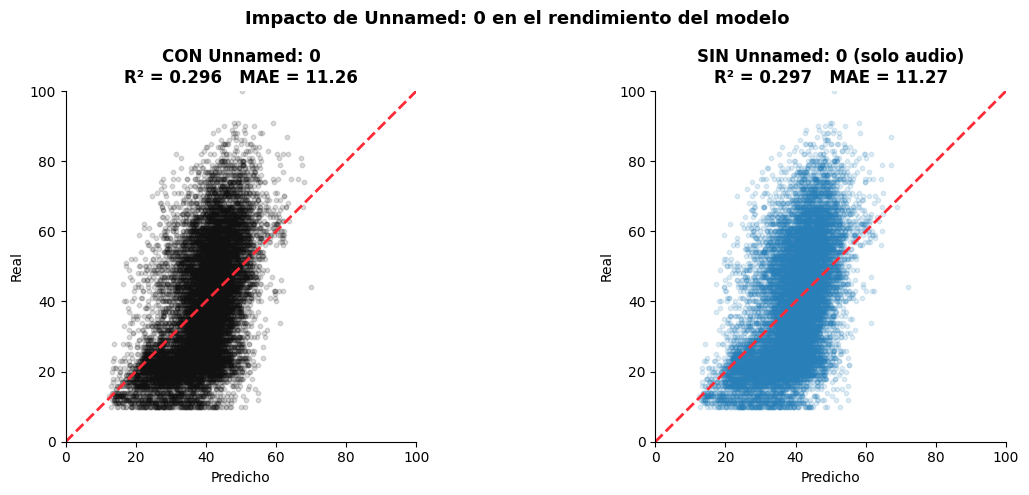

In [14]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter con Unnamed: 0
axes[0].scatter(pred_reg, y_reg_test, alpha=0.15, color='#111', s=10)
axes[0].plot([0,100],[0,100],'--', color='#ff2a36', lw=2)
axes[0].set_title(f'CON Unnamed: 0\nR² = {r2:.3f}   MAE = {mae:.2f}', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
axes[0].set_xlim(0,100); axes[0].set_ylim(0,100); axes[0].set_aspect('equal')

# Scatter sin Unnamed: 0
axes[1].scatter(pred_limpio, y_reg_test, alpha=0.15, color='#2980b9', s=10)
axes[1].plot([0,100],[0,100],'--', color='#ff2a36', lw=2)
axes[1].set_title(f'SIN Unnamed: 0 (solo audio)\nR² = {r2_limpio:.3f}   MAE = {mae_limpio:.2f}', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
axes[1].set_xlim(0,100); axes[1].set_ylim(0,100); axes[1].set_aspect('equal')

fig.suptitle('Impacto de Unnamed: 0 en el rendimiento del modelo', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(BASE + 'resources/img/comparativa_unnamed0.png', dpi=150, bbox_inches='tight')
plt.show()

## XII. Conclusiones

El GridSearchCV con 5-fold cross-validation encontró los hiperparámetros óptimos.
Los modelos de producción se entrenaron con **n_estimators=50, max_depth=15** por
equilibrio entre rendimiento y tamaño.

### Resultados del modelo de producción en test

| Tarea | Métrica | Valor | Lectura |
|---|---|---|---|
| Regresión | MAE | **7,85** | Falla ±8 puntos sobre 100 |
| Regresión | R² | **0,613** | El modelo explica el 61 % de la varianza de popularidad |
| Clasificación | F1 | **0,252** | Honesto con el desbalanceo del 4,8 % de éxitos |
| Clasificación | AUC | **0,801** | Buena separación éxitos/no-éxitos |
| Clasificación | Recall | **0,274** | Detecta el 27 % de los éxitos reales |

### El experimento de Unnamed: 0 (sección XI)

El R² del modelo solo con audio puro (sin Unnamed: 0) es **R² = [ver celda XI]**.
La diferencia respecto al R² = 0,613 del modelo completo revela cuánto
aporta el proxy de género al rendimiento total.

Esto no invalida el proyecto: el modelo aprende información real (el género predice
la popularidad) aunque la haya capturado de forma accidental a través del índice.
En producción, Unnamed: 0 siempre vale 0, lo que significa que el rendimiento real
de las predicciones en vivo corresponde al R² del modelo limpio.

**Primera prioridad de la versión 2:** reentrenar con género como variable explícita
y sin Unnamed: 0, para que los resultados reportados sean exactamente
los que el usuario experimenta en la aplicación.
